This notebook was created by Donna Faith Go.

In [27]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# tgcn model
import torch

# ignore warnings
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

## Selected Shock Periods and Stock Segmentation

According to the study, the three selected periods for this period are:
1. 2008 Financial Crisis (October 1-10, 2008)
2. 2016 U.S. Presidential Elections (October 25 - November 4, 2016)
3. Onset of the COVID-19 Pandemic (February 20-28, 2020)

These stocks were chosen for analysis:
<div align="center">
    <img src="figures/Selected stocks.png" width="40%">
</div>

In [2]:
selected_stocks = [
    "SHW", "ECL", "PPG",  # Materials
    "BA", "CAT", "MMM",   # Industrials
    "AMZN", "F", "NKE",   # Consumer Discretionary
    "PG", "KO", "PEP",    # Consumer Staples
    "JNJ", "PFE", "MRK",  # Healthcare
    "JPM", "BAC", "WFC",  # Financials
    "AAPL", "MSFT", "INTC",  # Information Technology
    "GOOGL", "T", "CMCSA",   # Communication Services
    "DUK", "SO", "D",     # Utilities
    "SPG", "AMT", "EQIX", # Real Estate
    "XOM", "CVX", "SLB"   # Energy
]

## Degree of Connection
Note for future Donna:
- I am not sure about this, but for this simulation, the degree of connection pertains to the number of connections for the selected stock. I just did this for daily stocks.
- I am only looking at the connections of the selected stocks; not of the other stocks that were not mentioned. They used the same methodology in the paper as well.

### Functions

In [25]:
def get_dataframe(date, folder_name):
    """
    Gets the adjacency matrix and turns it into a dataframe.
    """
    # read file for stocks
    filepath = f"checkpoints/closing df.pkl"
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    stocks = data.columns.to_list()

    # read file for adjacecny matrix
    filepath = f"{folder_name}/{date}.pkl"
    with open(filepath, "rb") as f:
        data = pickle.load(f)
        
    # get data
    adj_matrix = data['adjacency matrix']
    df = pd.DataFrame(adj_matrix, columns=stocks, index=stocks)
    return df

def get_actual_connection(start_date, end_date, directory, selected_stocks):
    """
    Get the actual connections from the granger causality.
    """
    # get the dates
    dates = pd.date_range(start=start_date, end=end_date, freq='B').to_list()
    dates = [str(date).split(" ")[0] for date in dates]

    # get the connection count per date
    connection_count = {}
    for date in dates:
        # get connections for only selected stocks
        adj_df = get_dataframe(date, folder_name=directory)
        adj_df = adj_df[[col for col in adj_df.columns if col in selected_stocks]]
        adj_df = adj_df.loc[[idx for idx in adj_df.index if idx in selected_stocks]]

        # get the number of connections per stock
        date_counts = {}
        for stock in selected_stocks:
            count_ones = (adj_df[stock] == 1).sum()
            date_counts[stock] = count_ones

        connection_count[date] = date_counts
    return connection_count

def get_predicted_connection(start_date, end_date, selected_stocks):
    """
    Get the predicted connections of the adjacency matrix 
    from the TGCN model.
    """
    
    # load TGCN model
    model = torch.load('best_tgcn_weights.pth')
    model.eval()
    
    return

def plot_degree_connection(start_date, end_date, directory, selected_stocks, mode="both"):
    # choose which one to plot
    if mode == "actual":
        # get connection
        actual_connections = get_actual_connection(start_date=start_date,
                                                   end_date=end_date,
                                                   directory = directory,
                                                   selected_stocks=selected_stocks)
        # turn to dataframe
        df = pd.DataFrame(actual_connections).T
        df = df.apply(pd.to_numeric)
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()
        
        # plotting
        fig, axes = plt.subplots(nrows=len(df), ncols=1, figsize=(15, 4*len(df)))
        if len(df) == 1:
            axes = [axes]
        
        for idx, (date, row) in enumerate(df.iterrows()):
            sorted_row = row.sort_values(ascending=False)            
            axes[idx].bar(sorted_row.index, sorted_row.values)
            axes[idx].set_title(f'Connections by Stock - {date.strftime("%Y-%m-%d")}')
            axes[idx].set_xlabel('Stock', fontsize=9)
            axes[idx].set_ylabel('Number of Connections', fontsize=9)
            
        plt.tight_layout()
        plt.show()
        
    elif mode == "predicted":
        pass
    elif mode == "both":
        pass
        
    return

### Experiments

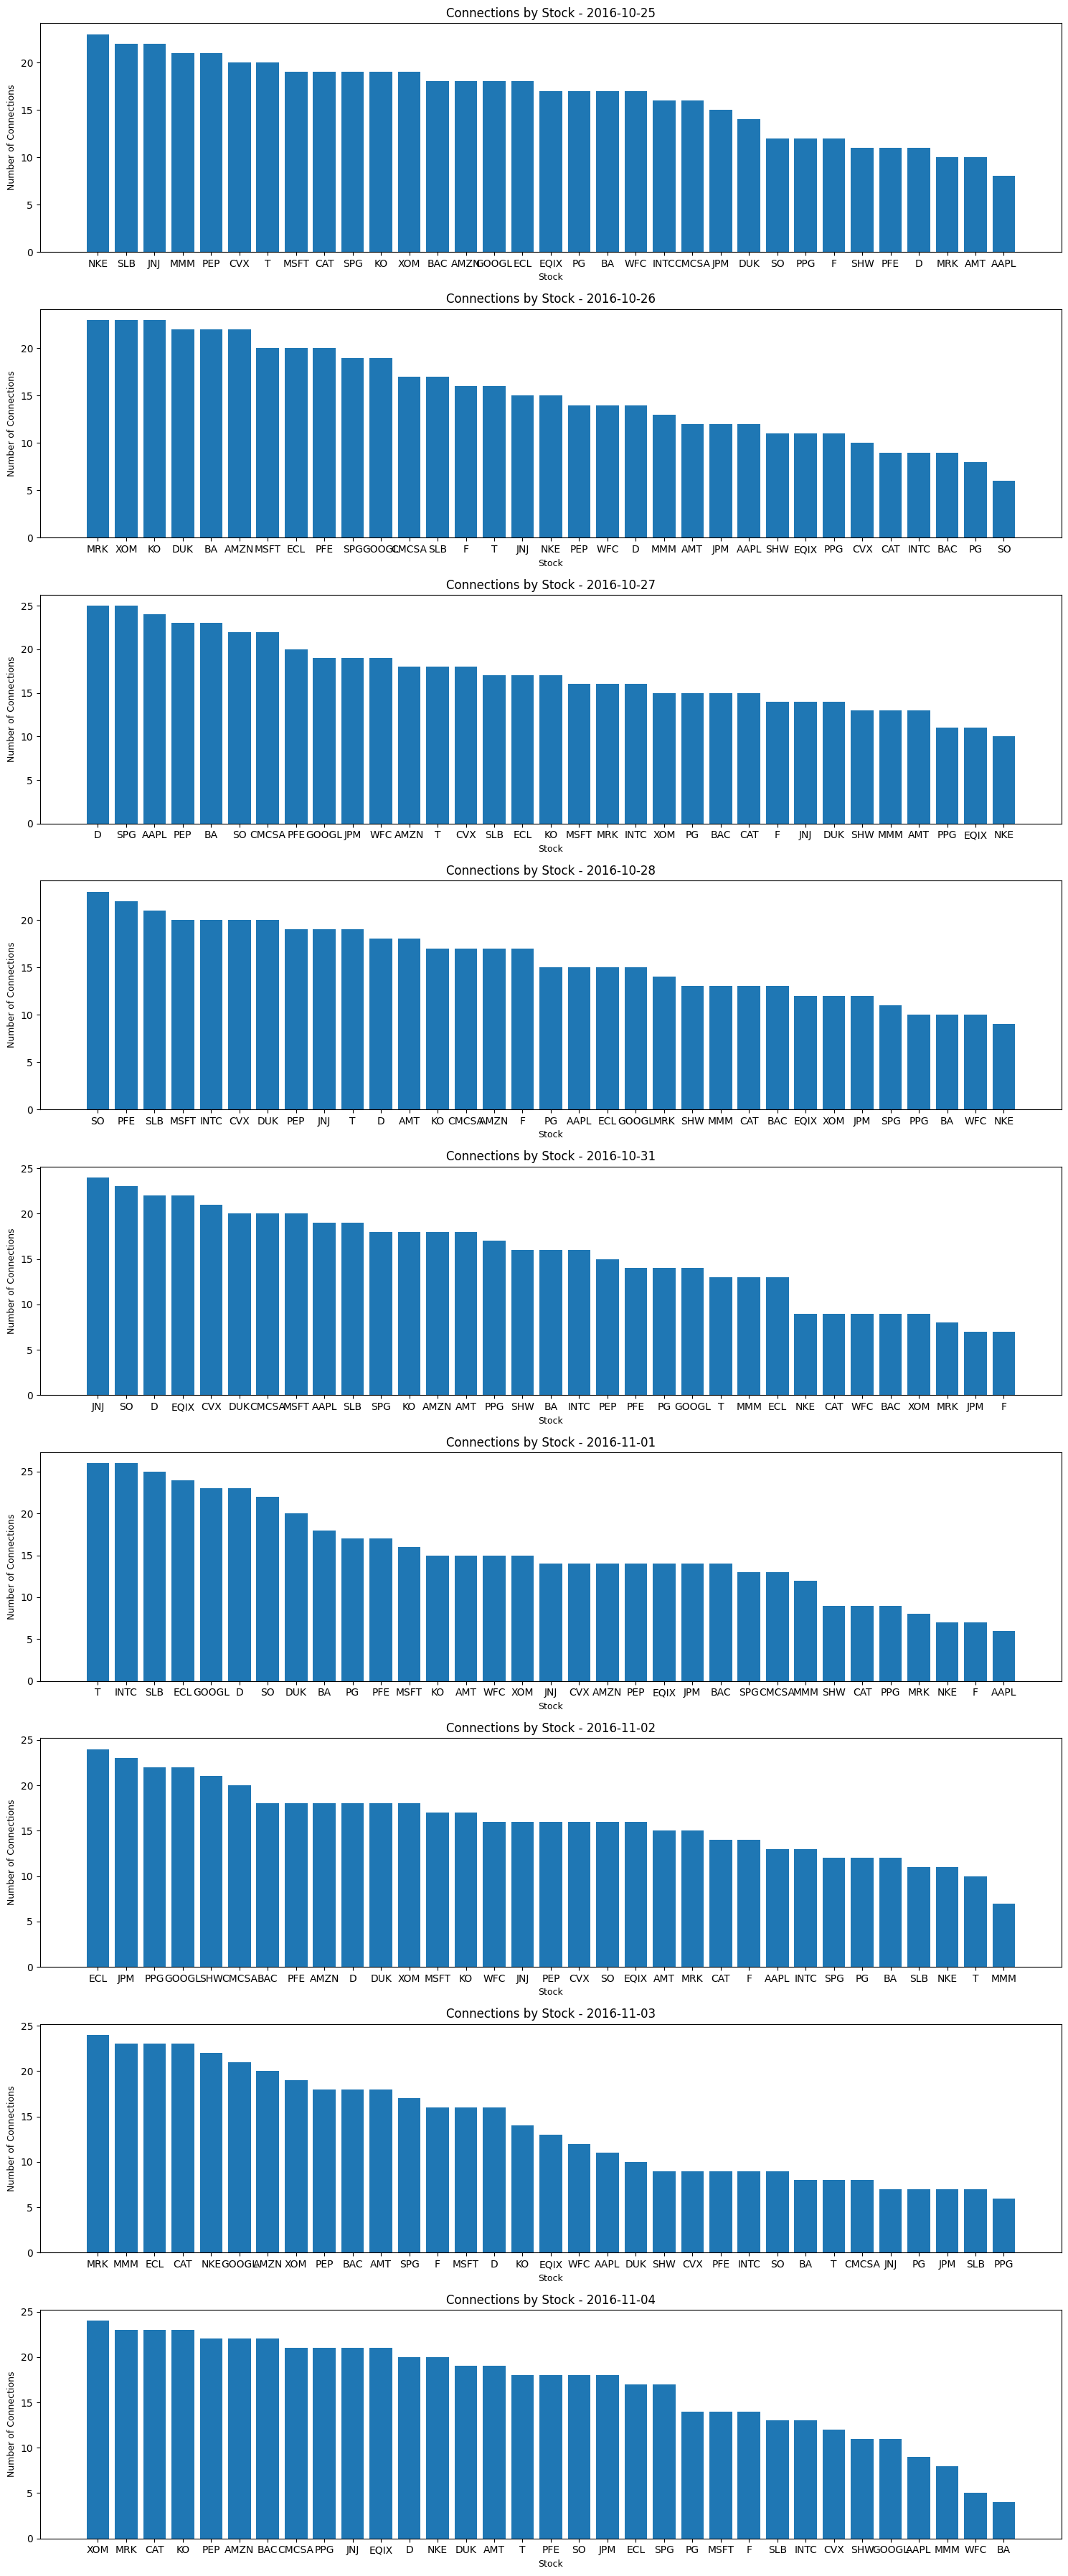

In [28]:
# global financial crisis
plot_degree_connection(start_date='2016-10-25', 
                      end_date='2016-11-04',
                      directory = "adjacency matrices 2",
                      selected_stocks=selected_stocks,
                      mode="actual")

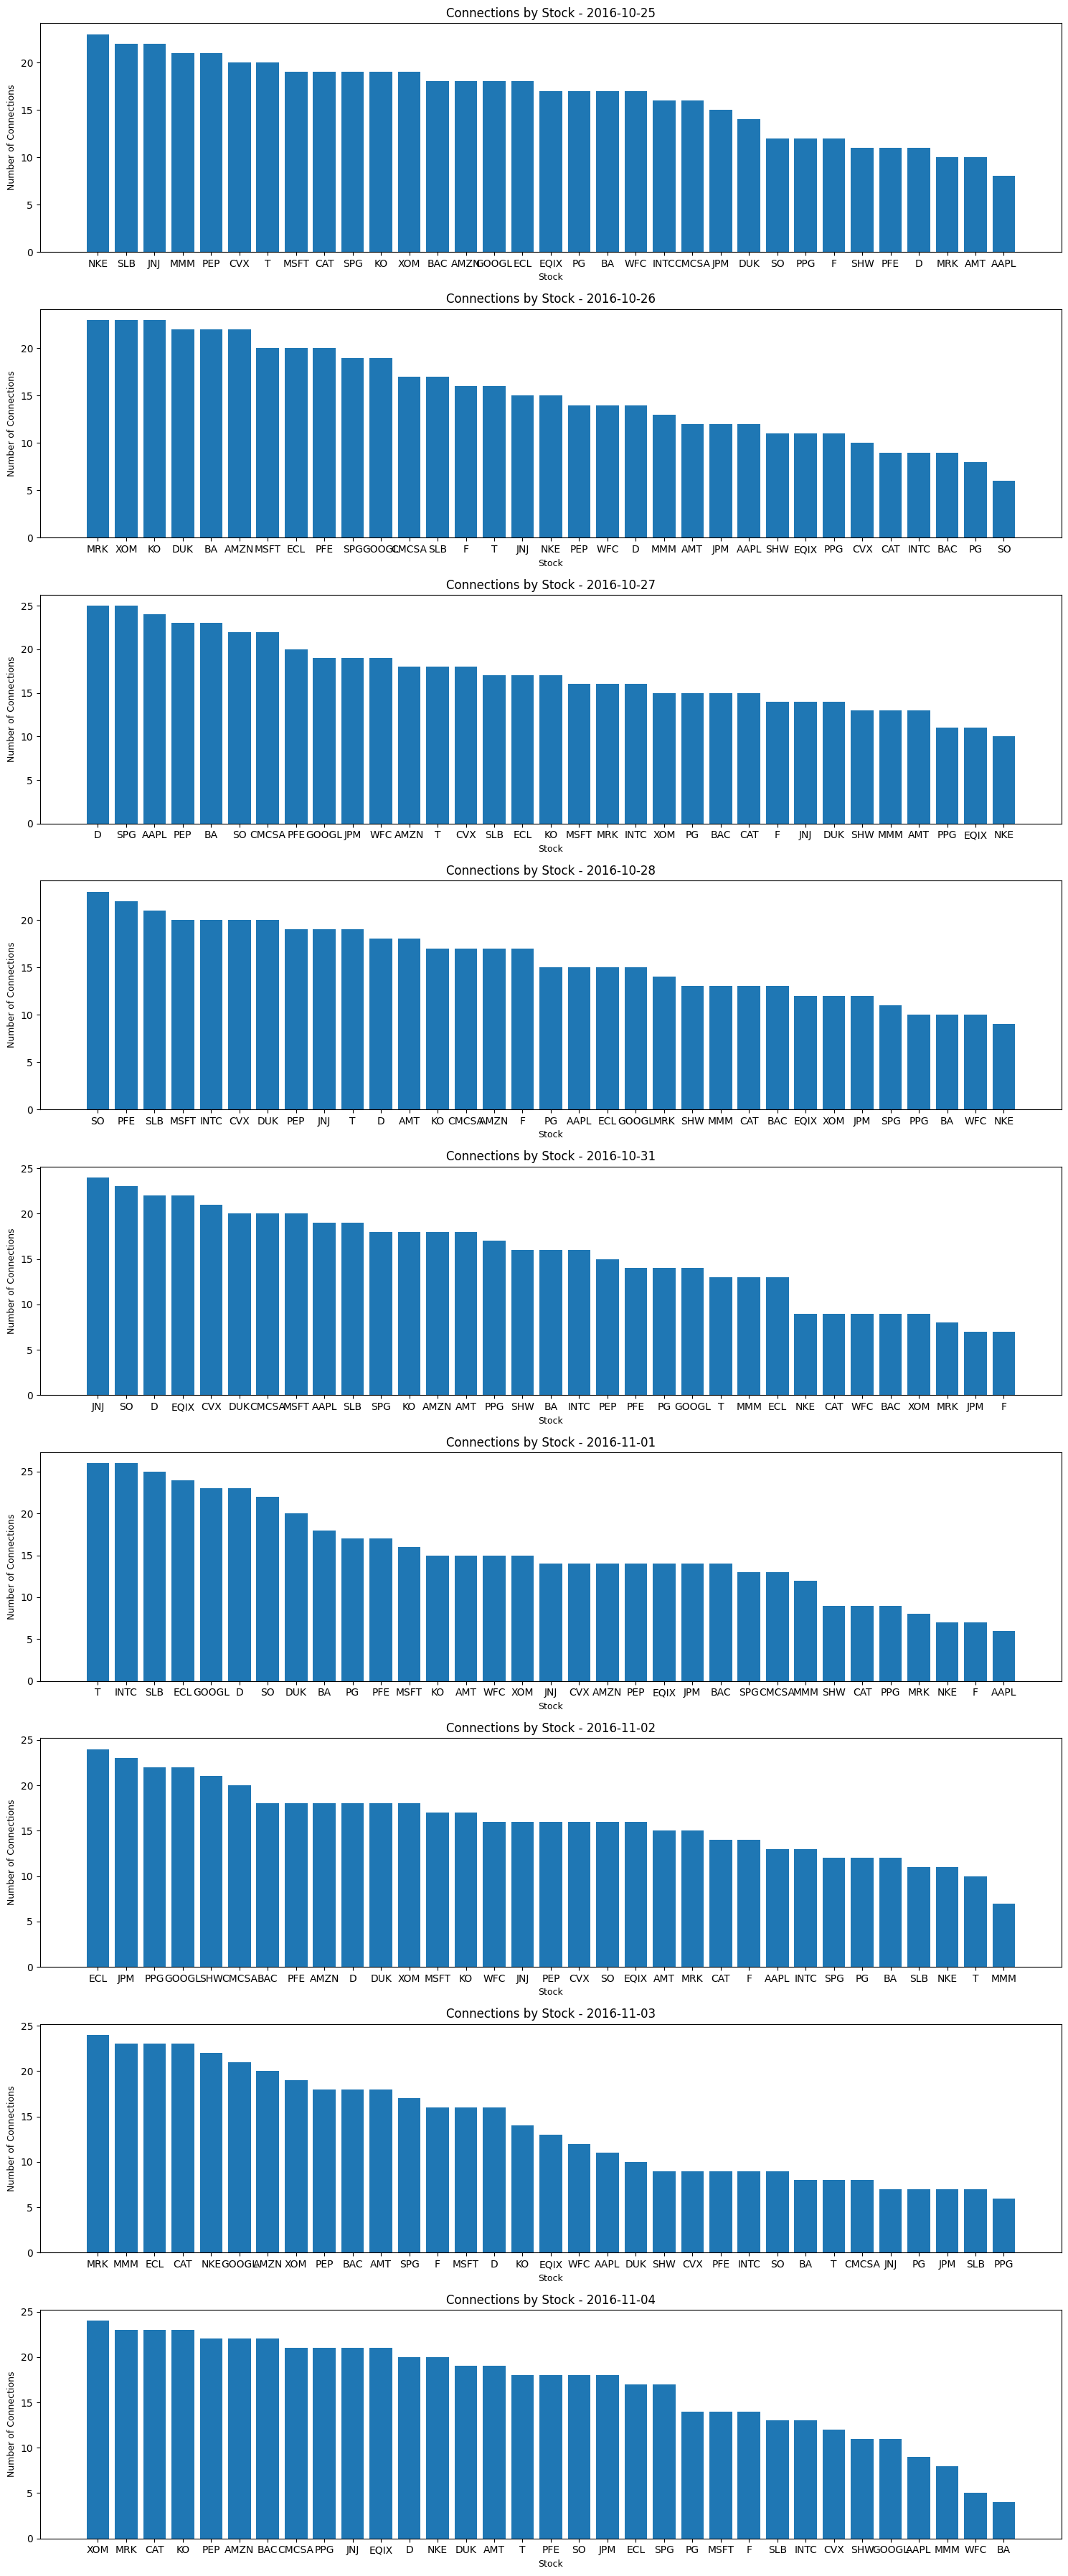

In [29]:
# 2016 presidential election
plot_degree_connection(start_date='2016-10-25', 
                      end_date='2016-11-04',
                      directory = "adjacency matrices 2",
                      selected_stocks=selected_stocks,
                      mode="actual")

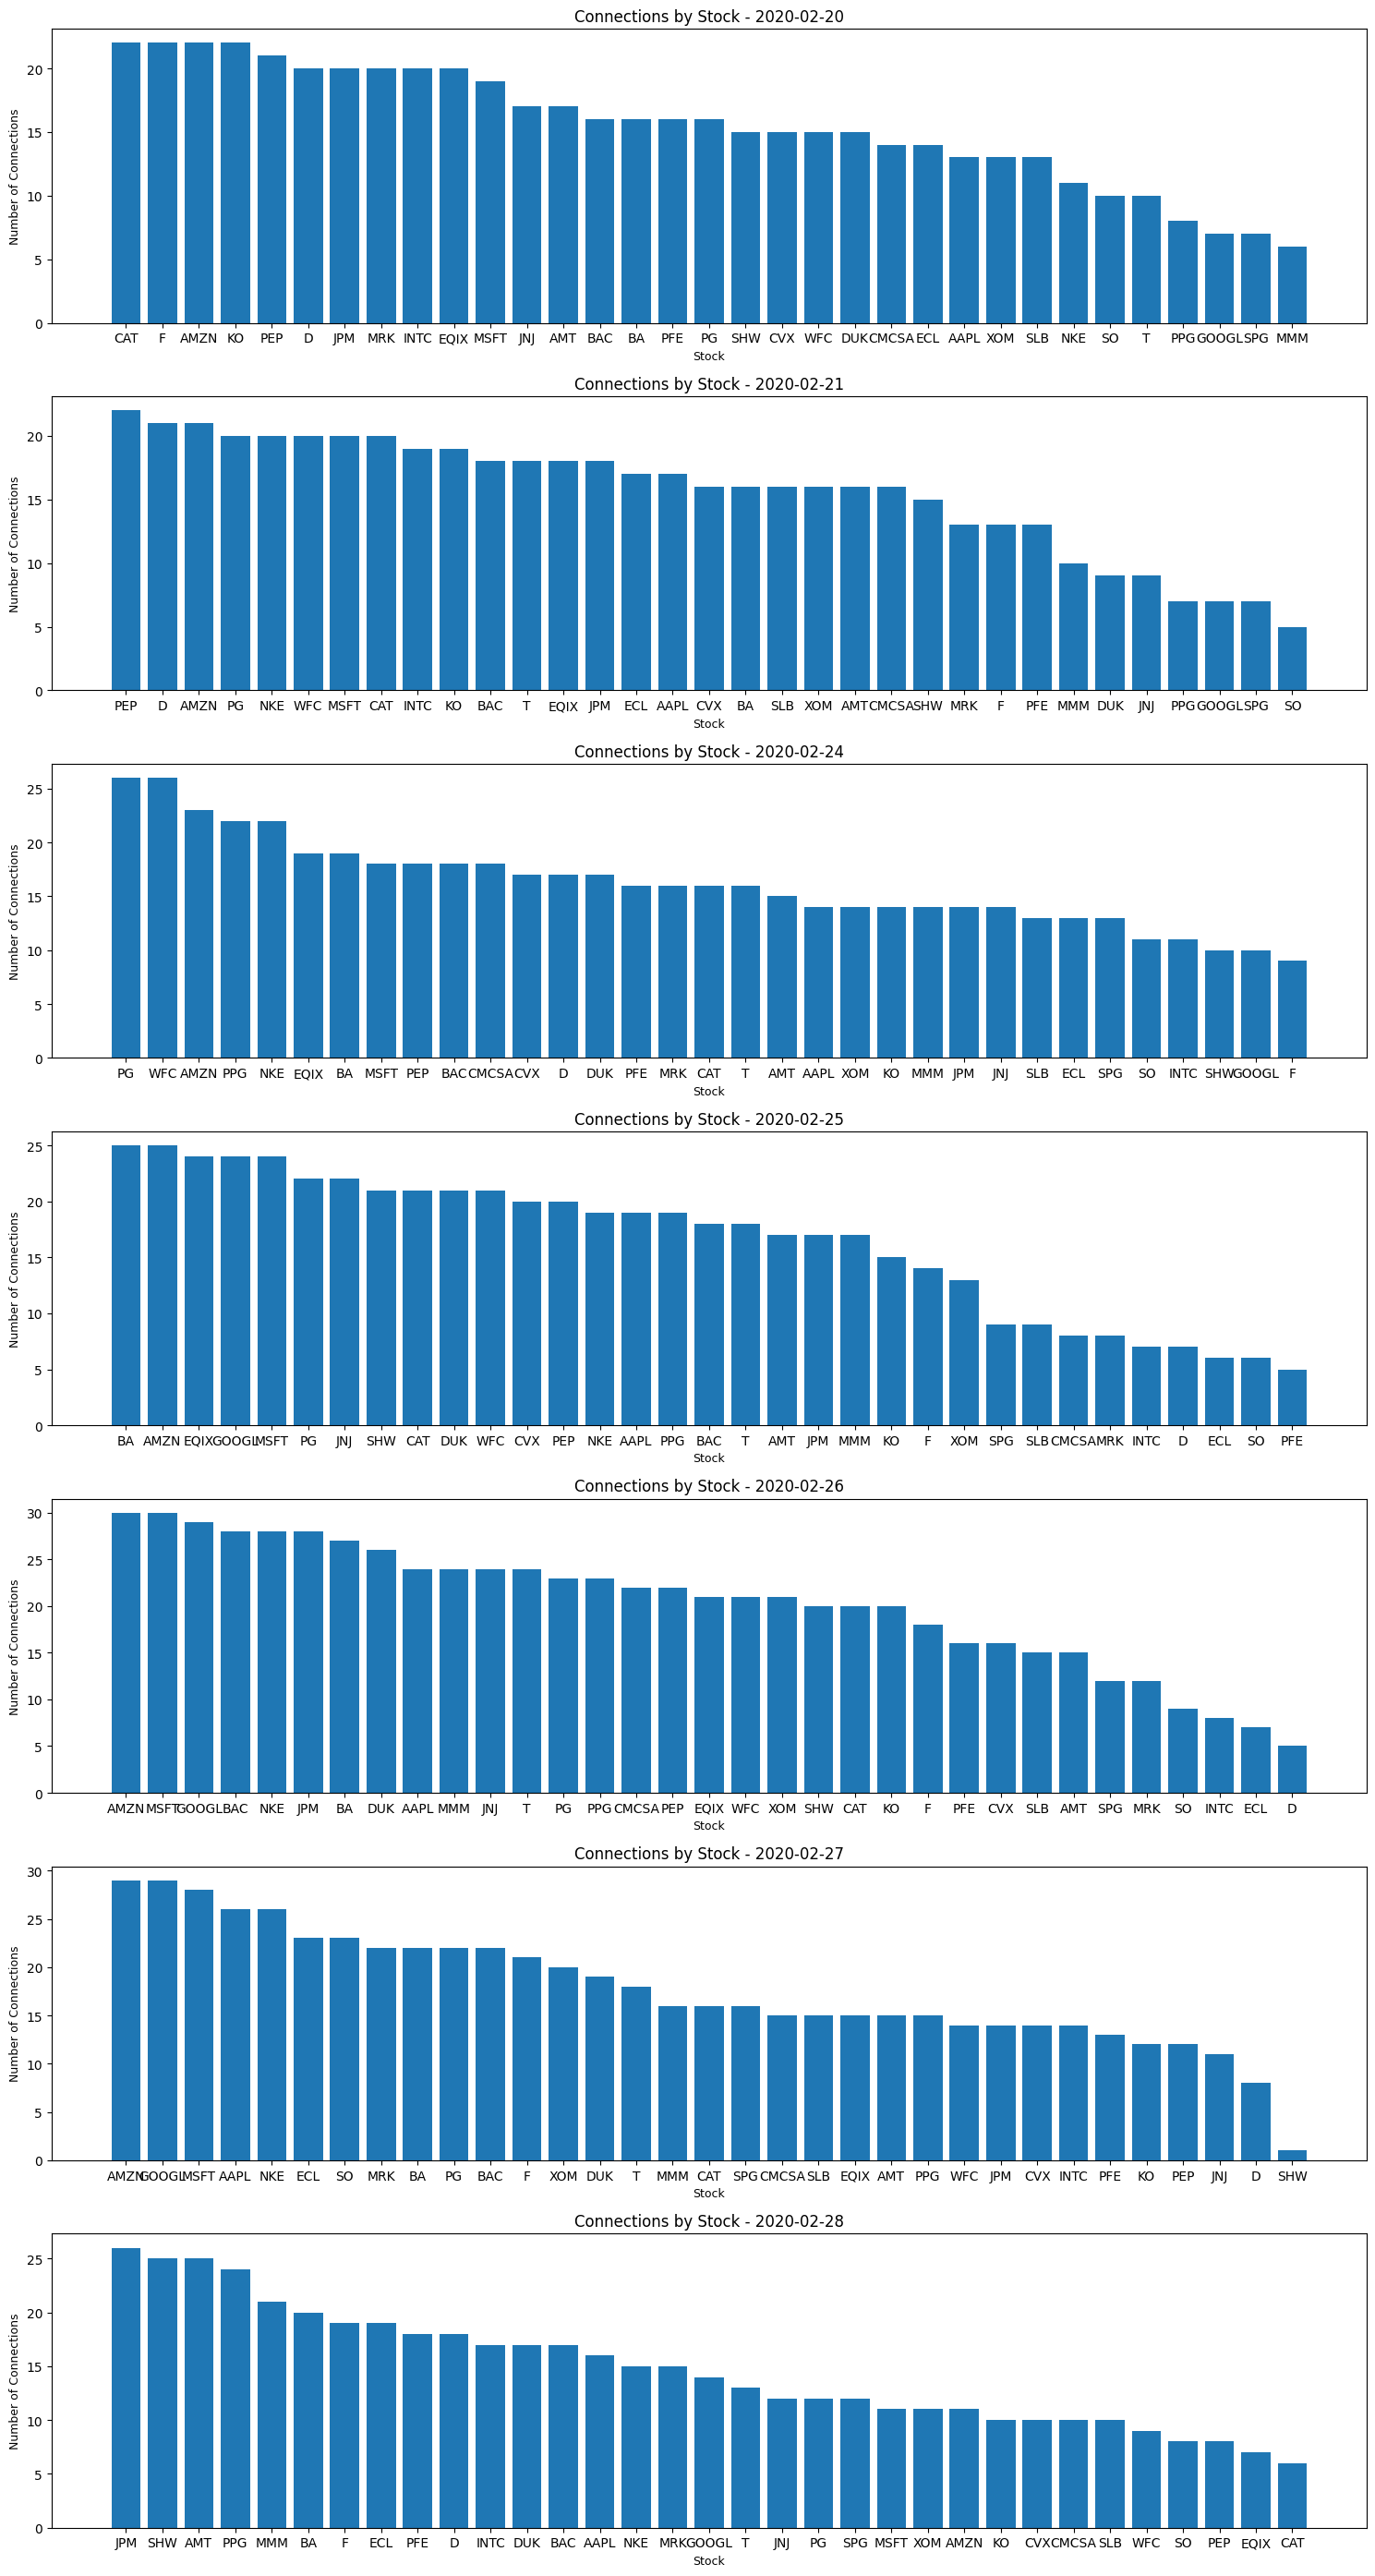

In [30]:
# onset of 2020 covid-19 pandemic
plot_degree_connection(start_date='2020-02-20', 
                      end_date='2020-02-28',
                      directory = "adjacency matrices 2",
                      selected_stocks=selected_stocks,
                      mode="actual")

## Betweeness, closeness, and degree centrality

Note for future self:
1. **Degree centrality**: Count a node's number of direct connections
2. **Betweenness centrality**: Gets a node's influence by counting how often a node lies on the shortest paths between other pairs of nodes.
3. **Closeness centrality**: How quickly a node can reach all other nodes in the network, with shorter average path distances indicating greater centrality.

### Functions

### Experiments

## Network indicators

Note for my future self:
- Network density: 
- Clustering coefficient:

### Functions

### Experiments

## Average Change and Amplitude

Note for my future self:
- Average change: average change in returns for each stock and sector, revealing the financial impact of the shock.
- Amplitude: amplitude of returns per stock and the average amplitude of returns per sector

### Functions

### Experiments